# Raw-patch ML baseline

Trains the same classifier battery used downstream on LC-KSVD2 sparse codes
(`lc_ksvd/inference/train.py`, `lc_ksvd/inference/classify.py`) directly on
the raw, flattened 12x12x12 voxel patches instead of on sparse codes `Gamma`.

Purpose: give a baseline number for "how much does the LC-KSVD dictionary /
sparse coding step actually buy us over classifying raw intensities", and
how much of that signal is just coarse per-patch intensity statistics
(mean/std HU) rather than spatial structure.

Models trained on the full 1728-dim raw patch:
- Logistic Regression (linear reference point)
- HistGradientBoostingClassifier (primary baseline -- nonlinear, handles
  raw HU-intensity features and class imbalance well out of the box)
- Linear SVM (LinearSVC), per-feature scaled with `MaxAbsScaler` -- second
  linear reference point, matches the SVM stage of the LC-KSVD2 sparse-code
  pipeline for a direct comparison
- Linear SVM (LinearSVC), per-patch scaled with `Normalizer(norm="l2")`
  instead of `MaxAbsScaler` -- tests whether normalizing away each patch's
  overall intensity magnitude (keeping only its relative voxel pattern)
  helps a linear SVM
- XGBoost -- second nonlinear tree baseline, same family as the LC-KSVD2
  pipeline's diagnostic classifier, cross-checks HistGBM's result

Ablation on a 2-feature summary (`mean_hu`, `std_hu` per patch, i.e.
collapsing all 1728 voxels to just their mean and standard deviation):
- Logistic Regression trained on `(mean_hu, std_hu)` only, evaluated
  against the same test set, to see how much of the raw-patch models'
  signal is captured by coarse intensity statistics alone versus full
  spatial structure

Also includes an EDA section (per-patch HU mean/std table, distribution
histograms, and a mean-vs-std scatter, all split by class) that the
mean/std ablation model above is built from.

CV is grouped by `scan_id` (GroupKFold) so patches from the same scan never
straddle a train/val split -- plain K-fold would leak across the ~800
patches/scan average and inflate CV scores.

In [4]:
import logging
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch

import lc_ksvd.config as lc_config
os.chdir(lc_config.__file__.rsplit("/lc_ksvd/", 1)[0] + "/lc_ksvd")  # config.OUTPUT_DIR is relative to this cwd
from lc_ksvd.config import MODELS_DIR, PATCHES_DIR, CLASS_ORDER
from lc_ksvd.patch_extractor.patch_extraction import load_unified_patch_matrix
from lc_ksvd.inference.evaluate import evaluate, save_classification_results

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

RANDOM_SEED = 42
TRAIN_PATCHES_PATH = PATCHES_DIR / "unified_train_shuffled.npz"

RAW_LOGREG_MODEL_PATH = MODELS_DIR / "raw_logreg_model.pkl"
RAW_GBM_MODEL_PATH = MODELS_DIR / "raw_gbm_model.pkl"
RAW_SVM_MODEL_PATH = MODELS_DIR / "raw_svm_model.pkl"
RAW_XGB_MODEL_PATH = MODELS_DIR / "raw_xgb_model.pkl"
RAW_RF_MODEL_PATH = MODELS_DIR / "raw_rf_model.pkl"
RAW_MLP_MODEL_PATH = MODELS_DIR / "raw_mlp_model.pkl"
RAW_NB_MODEL_PATH = MODELS_DIR / "raw_nb_model.pkl"
RAW_LGBM_MODEL_PATH = MODELS_DIR / "raw_lgbm_model.pkl"


MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Predictions/labels are cached here as .npy so any evaluate/summary cell can
# be re-run standalone (e.g. after a kernel restart) without needing every
# earlier cell re-executed in the same session first.
PREDS_DIR = MODELS_DIR.parent / "preds"
PREDS_DIR.mkdir(parents=True, exist_ok=True)
Y_TEST_PATH = PREDS_DIR / "y_test.npy"
SCAN_IDS_TEST_PATH = PREDS_DIR / "scan_ids_test.npy"
MODEL_NAMES = [
    "raw_logreg", "raw_gbm", "raw_svm", "raw_svm_l2", "raw_xgb", "raw_lgbm",
    "raw_rf", "raw_mlp", "raw_nb", "raw_meanstd_gbm", "hu_meanstd_logreg",
]


def pred_path(model_name):
    return PREDS_DIR / f"{model_name}_ypred_test.npy"
import itertools
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from tqdm.auto import tqdm


def grid_search_with_progress(
    estimator, param_grid: dict, X, y, groups, cv_splits=5, desc="", sample_weight=None,
):
    """Manual grid search over `param_grid` with a visible per-combination progress bar.

    Equivalent to GridSearchCV(cv=GroupKFold(cv_splits)), but ticks tqdm once
    per hyperparameter combination -- joblib's own progress callback doesn't
    reliably surface in every notebook frontend/joblib version, so this
    drives the loop explicitly instead of patching joblib internals.
    Pass `sample_weight` for estimators with no built-in `class_weight`
    support (XGBoost, GaussianNB, MLPClassifier) -- it's routed through
    cross_val_score's per-fold fit params (correctly sliced per CV split)
    and used again for the final refit on all of `X`/`y`.
    """
    cv = GroupKFold(n_splits=cv_splits)
    keys = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    fit_params = {"sample_weight": sample_weight} if sample_weight is not None else {}

    best_score = -np.inf
    best_params = None
    for combo in tqdm(combos, desc=desc):
        params = dict(zip(keys, combo))
        candidate = clone(estimator).set_params(**params)
        scores = cross_val_score(
            candidate, X, y, groups=groups, cv=cv, scoring="f1_macro", n_jobs=-1,
            params=fit_params,
        )
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print("\nBest parameters:", best_params)
    print("Best CV f1_macro:", best_score)

    best_estimator = clone(estimator).set_params(**best_params)
    best_estimator.fit(X, y, **fit_params)
    return best_estimator
def load_filtered_train_data():
    """Load unified_train_shuffled.npz, dropping any scan that also appears
    in the test split.

    11 scans leak between the pre-extracted patch files: 5 of the 11 "2c"
    test scans and all 10 of the "2d" test scans are also present in the
    per-class train files (unified_train_2c.npz / unified_train_2d.npz).
    Training on those scans and then evaluating on them inflates GGO/nodule
    test metrics -- the model has already seen those patients' patches.
    "normal" has zero overlap and is unaffected.
    """
    data = np.load(TRAIN_PATCHES_PATH, allow_pickle=True)
    X, y, groups = data["X"].T, data["H"], data["scan_ids"]

    test_scan_ids = set()
    for cls in CLASS_ORDER:
        test_scan_ids |= set(
            np.load(PATCHES_DIR / f"unified_test_{cls}.npz", allow_pickle=True)["scan_ids"].tolist()
        )

    leak_mask = np.isin(groups, list(test_scan_ids))
    if leak_mask.any():
        logger.info(
            f"Dropping {leak_mask.sum()} train patches from "
            f"{len(set(groups[leak_mask].tolist()))} scans that also appear in the test set."
        )
    return X[~leak_mask], y[~leak_mask], groups[~leak_mask]


/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load train patches

In [5]:
X_train, y_train, groups_train = load_filtered_train_data()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"scans:   {len(np.unique(groups_train))}")
for i, cls in enumerate(CLASS_ORDER):
    print(f"  {cls}: {int((y_train == i).sum())} patches")

INFO Dropping 10434 train patches from 11 scans that also appear in the test set.


X_train: (83551, 1728), y_train: (83551,)
scans:   105
  normal: 53700 patches
  2c: 19217 patches
  2d: 10634 patches


## Train: Logistic Regression (linear baseline)

In [58]:
def train_logreg(X, y, groups, cv_splits=5):
    pipeline = Pipeline([
        ("scaler", MaxAbsScaler()),
        ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ])
    param_grid = {"logreg__C": [0.1, 1.0, 10.0, 100.0]}
    return grid_search_with_progress(
        pipeline, param_grid, X, y, groups, cv_splits=cv_splits, desc="LogReg grid search",
    )


if RAW_LOGREG_MODEL_PATH.exists():
    logger.info(f"LogReg model exists at: {RAW_LOGREG_MODEL_PATH}")
    logreg_clf = joblib.load(RAW_LOGREG_MODEL_PATH)
else:
    logreg_clf = train_logreg(X_train, y_train, groups_train)
    joblib.dump(logreg_clf, RAW_LOGREG_MODEL_PATH)
    logger.info(f"Saved LogReg model -> {RAW_LOGREG_MODEL_PATH}")

INFO LogReg model exists at: outputs/models/raw_logreg_model.pkl


## Train: HistGradientBoostingClassifier (nonlinear baseline)

In [59]:
def train_gbm(X, y, groups, cv_splits=5):
    clf = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_SEED)
    param_grid = {"max_depth": [3, 5, None], "learning_rate": [0.05, 0.1]}
    return grid_search_with_progress(
        clf, param_grid, X, y, groups, cv_splits=cv_splits, desc="GBM grid search",
    )


if RAW_GBM_MODEL_PATH.exists():
    logger.info(f"GBM model exists at: {RAW_GBM_MODEL_PATH}")
    gbm_clf = joblib.load(RAW_GBM_MODEL_PATH)
else:
    gbm_clf = train_gbm(X_train, y_train, groups_train)
    joblib.dump(gbm_clf, RAW_GBM_MODEL_PATH)
    logger.info(f"Saved GBM model -> {RAW_GBM_MODEL_PATH}")

INFO GBM model exists at: outputs/models/raw_gbm_model.pkl


## Train: Linear SVM (LinearSVC)

In [60]:
def train_svm(X, y, groups, cv_splits=5):
    pipeline = Pipeline([
        ("scaler", MaxAbsScaler()),
        ("svm", LinearSVC(dual=False, max_iter=10000, class_weight="balanced")),
    ])
    param_grid = {"svm__C": [0.1, 1.0, 10.0, 100.0]}
    return grid_search_with_progress(
        pipeline, param_grid, X, y, groups, cv_splits=cv_splits, desc="SVM grid search",
    )


if RAW_SVM_MODEL_PATH.exists():
    logger.info(f"SVM model exists at: {RAW_SVM_MODEL_PATH}")
    svm_clf = joblib.load(RAW_SVM_MODEL_PATH)
else:
    svm_clf = train_svm(X_train, y_train, groups_train)
    joblib.dump(svm_clf, RAW_SVM_MODEL_PATH)
    logger.info(f"Saved SVM model -> {RAW_SVM_MODEL_PATH}")

INFO SVM model exists at: outputs/models/raw_svm_model.pkl


## Train: Linear SVM with L2-normalized patches

Same LinearSVC setup as the plain SVM baseline, but each patch's 1728-dim
raw voxel vector is rescaled to unit L2 norm (`Normalizer(norm="l2")`)
before fitting, instead of the per-feature `MaxAbsScaler` used elsewhere --
i.e. per-sample normalization rather than per-feature scaling. Tests
whether normalizing away each patch's overall intensity magnitude (while
keeping its relative voxel-to-voxel pattern) helps a linear SVM separate
the classes.


In [61]:
from sklearn.preprocessing import Normalizer

RAW_SVM_L2_MODEL_PATH = MODELS_DIR / "raw_svm_l2_model.pkl"

def train_svm_l2(X, y, groups, cv_splits=5):
    pipeline = Pipeline([
        ("l2norm", Normalizer(norm="l2")),
        ("svm", LinearSVC(dual=False, max_iter=10000, class_weight="balanced")),
    ])
    param_grid = {"svm__C": [0.1, 1.0, 10.0, 100.0]}
    return grid_search_with_progress(
        pipeline, param_grid, X, y, groups, cv_splits=cv_splits, desc="SVM (L2-normalized) grid search",
    )


if RAW_SVM_L2_MODEL_PATH.exists():
    logger.info(f"SVM (L2) model exists at: {RAW_SVM_L2_MODEL_PATH}")
    svm_l2_clf = joblib.load(RAW_SVM_L2_MODEL_PATH)
else:
    svm_l2_clf = train_svm_l2(X_train, y_train, groups_train)
    joblib.dump(svm_l2_clf, RAW_SVM_L2_MODEL_PATH)
    logger.info(f"Saved SVM (L2) model -> {RAW_SVM_L2_MODEL_PATH}")


INFO SVM (L2) model exists at: outputs/models/raw_svm_l2_model.pkl


## Train: XGBoost (nonlinear baseline)

In [62]:
def train_xgb(X, y, groups, cv_splits=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    clf = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        device=device,
        random_state=RANDOM_SEED,
    )
    param_grid = {
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1],
        "reg_lambda": [1.0, 5.0],
    }
    sample_weight = compute_sample_weight("balanced", y)
    return grid_search_with_progress(
        clf, param_grid, X, y, groups, cv_splits=cv_splits, desc="XGBoost grid search",
        sample_weight=sample_weight,
    )


if RAW_XGB_MODEL_PATH.exists():
    logger.info(f"XGB model exists at: {RAW_XGB_MODEL_PATH}")
    xgb_clf = joblib.load(RAW_XGB_MODEL_PATH)
else:
    xgb_clf = train_xgb(X_train, y_train, groups_train)
    joblib.dump(xgb_clf, RAW_XGB_MODEL_PATH)
    logger.info(f"Saved XGB model -> {RAW_XGB_MODEL_PATH}")

INFO XGB model exists at: outputs/models/raw_xgb_model.pkl


## Load test patches

Loaded per-class (`unified_test_{class}.npz`) and concatenated via
`load_unified_patch_matrix`, matching how `classify.py` loads the test split
for the LC-KSVD2 pipeline.

In [42]:
X_test_raw, y_test, scan_ids_test, _coords_test = load_unified_patch_matrix(split="test")
X_test = X_test_raw.T  # (n_patches, n_features)

print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
for i, cls in enumerate(CLASS_ORDER):
    print(f"  {cls}: {int((y_test == i).sum())} patches")

np.save(Y_TEST_PATH, y_test)
np.save(SCAN_IDS_TEST_PATH, scan_ids_test)

INFO Loaded matrix: X=(1728, 69571), H=(69571,), scan_ids=(69571,), coords=(69571, 3)


X_test: (69571, 1728), y_test: (69571,)
  normal: 58764 patches
  2c: 8019 patches
  2d: 2788 patches


## Evaluate: Logistic Regression

In [43]:
if "logreg_clf" not in dir():
    if RAW_LOGREG_MODEL_PATH.exists():
        logreg_clf = joblib.load(RAW_LOGREG_MODEL_PATH)
    else:
        logger.info("raw_logreg_model.pkl not found -- training it now.")
        if "X_train" not in dir():
            X_train, y_train, groups_train = load_filtered_train_data()
        logreg_clf = train_logreg(X_train, y_train, groups_train)
        joblib.dump(logreg_clf, RAW_LOGREG_MODEL_PATH)
        logger.info(f"Saved LogReg model -> {RAW_LOGREG_MODEL_PATH}")

y_pred_logreg = logreg_clf.predict(X_test)
np.save(pred_path("raw_logreg"), y_pred_logreg)
print("=== Raw-patch LogisticRegression ===")
evaluate(y_pred_logreg, y_test)

save_classification_results(
    predictions=y_pred_logreg,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="raw_logreg",
    model_config={"logreg_params": logreg_clf.get_params()},
    split="test",
)


INFO Saved classification results -> outputs/results/raw_logreg_test_20260807_162116


=== Raw-patch LogisticRegression ===
Accuracy: 0.7804

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90     58764
           1       0.43      0.57      0.49      8019
           2       0.08      0.25      0.13      2788

    accuracy                           0.78     69571
   macro avg       0.49      0.55      0.50     69571
weighted avg       0.87      0.78      0.82     69571


Confusion Matrix:
[[48989  4212  5563]
 [ 1233  4595  2191]
 [  122  1960   706]]


PosixPath('outputs/results/raw_logreg_test_20260807_162116')

## Evaluate: HistGradientBoostingClassifier

In [44]:
if "gbm_clf" not in dir():
    if RAW_GBM_MODEL_PATH.exists():
        gbm_clf = joblib.load(RAW_GBM_MODEL_PATH)
    else:
        logger.info("raw_gbm_model.pkl not found -- training it now.")
        if "X_train" not in dir():
            X_train, y_train, groups_train = load_filtered_train_data()
        gbm_clf = train_gbm(X_train, y_train, groups_train)
        joblib.dump(gbm_clf, RAW_GBM_MODEL_PATH)
        logger.info(f"Saved GBM model -> {RAW_GBM_MODEL_PATH}")

y_pred_gbm = gbm_clf.predict(X_test)
np.save(pred_path("raw_gbm"), y_pred_gbm)
print("=== Raw-patch HistGradientBoostingClassifier ===")
evaluate(y_pred_gbm, y_test)

save_classification_results(
    predictions=y_pred_gbm,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="raw_gbm",
    model_config={"gbm_params": gbm_clf.get_params()},
    split="test",
)


INFO Saved classification results -> outputs/results/raw_gbm_test_20260807_162117


=== Raw-patch HistGradientBoostingClassifier ===
Accuracy: 0.8379

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     58764
           1       0.52      0.56      0.54      8019
           2       0.24      0.55      0.33      2788

    accuracy                           0.84     69571
   macro avg       0.57      0.67      0.60     69571
weighted avg       0.88      0.84      0.86     69571


Confusion Matrix:
[[52238  3073  3453]
 [ 2068  4518  1433]
 [  158  1091  1539]]


PosixPath('outputs/results/raw_gbm_test_20260807_162117')

## Evaluate: Linear SVM

In [45]:
if "svm_clf" not in dir():
    if RAW_SVM_MODEL_PATH.exists():
        svm_clf = joblib.load(RAW_SVM_MODEL_PATH)
    else:
        logger.info("raw_svm_model.pkl not found -- training it now.")
        if "X_train" not in dir():
            X_train, y_train, groups_train = load_filtered_train_data()
        svm_clf = train_svm(X_train, y_train, groups_train)
        joblib.dump(svm_clf, RAW_SVM_MODEL_PATH)
        logger.info(f"Saved SVM model -> {RAW_SVM_MODEL_PATH}")

y_pred_svm = svm_clf.predict(X_test)
np.save(pred_path("raw_svm"), y_pred_svm)
print("=== Raw-patch LinearSVC ===")
evaluate(y_pred_svm, y_test)

save_classification_results(
    predictions=y_pred_svm,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="raw_svm",
    model_config={"svm_params": svm_clf.get_params()},
    split="test",
)

INFO Saved classification results -> outputs/results/raw_svm_test_20260807_162117


=== Raw-patch LinearSVC ===
Accuracy: 0.8538

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     58764
           1       0.46      0.63      0.53      8019
           2       0.17      0.10      0.12      2788

    accuracy                           0.85     69571
   macro avg       0.53      0.55      0.53     69571
weighted avg       0.86      0.85      0.86     69571


Confusion Matrix:
[[54117  3623  1024]
 [ 2708  5016   295]
 [  263  2255   270]]


PosixPath('outputs/results/raw_svm_test_20260807_162117')

## Evaluate: XGBoost

In [46]:
if "xgb_clf" not in dir():
    if RAW_XGB_MODEL_PATH.exists():
        xgb_clf = joblib.load(RAW_XGB_MODEL_PATH)
    else:
        logger.info("xgb_model.pkl not found -- training it now.")
        if "X_train" not in dir():
            X_train, y_train, groups_train = load_filtered_train_data()
        xgb_clf = train_xgb(X_train, y_train, groups_train)
        joblib.dump(xgb_clf, RAW_XGB_MODEL_PATH)
        logger.info(f"Saved XGB model -> {RAW_XGB_MODEL_PATH}")

y_pred_xgb = xgb_clf.predict(X_test)
np.save(pred_path("raw_xgb"), y_pred_xgb)
print("=== Raw-patch XGBoost ===")
evaluate(y_pred_xgb, y_test)

save_classification_results(
    predictions=y_pred_xgb,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="raw_xgb",
    model_config={"xgb_params": xgb_clf.get_params()},
    split="test",
)

INFO Saved classification results -> outputs/results/raw_xgb_test_20260807_162117


=== Raw-patch XGBoost ===
Accuracy: 0.8316

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     58764
           1       0.50      0.58      0.54      8019
           2       0.22      0.50      0.31      2788

    accuracy                           0.83     69571
   macro avg       0.56      0.65      0.59     69571
weighted avg       0.88      0.83      0.85     69571


Confusion Matrix:
[[51825  3364  3575]
 [ 2074  4634  1311]
 [  144  1246  1398]]


PosixPath('outputs/results/raw_xgb_test_20260807_162117')

## Evaluate: Linear SVM (L2-normalized)

Predicts on the test set with `svm_l2_clf`, prints the accuracy/classification
report/confusion matrix via `evaluate()`, and saves results with
`save_classification_results()` under model name `raw_svm_l2` -- same
evaluate/save pattern as the other raw-patch models, for direct comparison
against the plain (MaxAbsScaler) SVM baseline.


In [47]:
if "svm_l2_clf" not in dir():
    if RAW_SVM_L2_MODEL_PATH.exists():
        svm_l2_clf = joblib.load(RAW_SVM_L2_MODEL_PATH)
    else:
        logger.info("raw_svm_l2_model.pkl not found -- training it now.")
        if "X_train" not in dir():
            X_train, y_train, groups_train = load_filtered_train_data()
        svm_l2_clf = train_svm_l2(X_train, y_train, groups_train)
        joblib.dump(svm_l2_clf, RAW_SVM_L2_MODEL_PATH)
        logger.info(f"Saved SVM (L2) model -> {RAW_SVM_L2_MODEL_PATH}")

y_pred_svm_l2 = svm_l2_clf.predict(X_test)
np.save(pred_path("raw_svm_l2"), y_pred_svm_l2)
print("=== Raw-patch LinearSVC (L2-normalized) ===")
evaluate(y_pred_svm_l2, y_test)

save_classification_results(
    predictions=y_pred_svm_l2,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="raw_svm_l2",
    model_config={"svm_params": svm_l2_clf.get_params()},
    split="test",
)


INFO Saved classification results -> outputs/results/raw_svm_l2_test_20260807_162118


=== Raw-patch LinearSVC (L2-normalized) ===
Accuracy: 0.8425

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     58764
           1       0.33      0.21      0.25      8019
           2       0.40      0.38      0.39      2788

    accuracy                           0.84     69571
   macro avg       0.54      0.51      0.52     69571
weighted avg       0.82      0.84      0.83     69571


Confusion Matrix:
[[55889  1973   902]
 [ 5676  1673   670]
 [  275  1459  1054]]


PosixPath('outputs/results/raw_svm_l2_test_20260807_162118')

## Side-by-side summary: per-class metrics (disk-backed)

Same per-class precision/recall/f1/one-vs-rest-accuracy breakdown as
before, but standalone-safe -- reloads `y_test` and each model's saved
predictions from disk (via `pred_path(model_name)`) instead of relying on
in-memory `y_pred_*` variables, so this cell (and the summary above it)
can be re-run on their own without re-executing every train/evaluate cell
first. Skips any model in `MODEL_NAMES` whose prediction file hasn't been
saved yet.


In [66]:
from sklearn.metrics import precision_recall_fscore_support


def per_class_metrics(y_true, y_pred, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CLASS_ORDER)), zero_division=0
    )
    rows = []
    for i, cls in enumerate(CLASS_ORDER):
        class_mask_true = (y_true == i)
        class_mask_pred = (y_pred == i)
        accuracy = (class_mask_true == class_mask_pred).mean()  # one-vs-rest accuracy
        rows.append({
            "model": model_name,
            "class": cls,
            "support": int(support[i]),
            "accuracy": accuracy,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
        })
    return rows


# Standalone-safe: same disk-backed pattern as the summary cell above.
y_test_disk = y_test if "y_test" in dir() else np.load(Y_TEST_PATH)

per_class_rows = []
for model_name in MODEL_NAMES:
    p = pred_path(model_name)
    if not p.exists():
        continue
    y_pred = np.load(p)
    per_class_rows += per_class_metrics(y_test_disk, y_pred, model_name)

per_class_summary = pd.DataFrame(per_class_rows)
per_class_summary

,model,class,support,accuracy,precision,recall,f1
0,raw_logreg,normal,58764,0.840020,0.973085,0.833657,0.897991
1,raw_logreg,2c,8019,0.862069,0.426767,0.573014,0.489194
2,raw_logreg,2d,2788,0.858619,0.083452,0.253228,0.125533
3,raw_gbm,normal,58764,0.874200,0.959129,0.888946,0.922705
4,raw_gbm,2c,8019,0.889825,0.520387,0.563412,0.541045
5,raw_gbm,2d,2788,0.911817,0.239533,0.552009,0.334093
6,raw_svm,normal,58764,0.890500,0.947958,0.920921,0.934244
7,raw_svm,2c,8019,0.872346,0.460437,0.625514,0.530429
8,raw_svm,2d,2788,0.944848,0.169918,0.096844,0.123372
9,raw_svm_l2,normal,58764,0.873137,0.903768,0.951075,0.926818


## EDA: per-patch HU mean/std distribution (filtered train set)

Patches are stored normalised to [-1, 1] (raw HU clipped to the
[-1000, 1000] lung window, then divided by 1000 -- see `LOWER_HU`/`UPPER_HU`
in `config.py`). Multiplying back by 1000 recovers the original HU scale for
this plot. For every patch in the leakage-filtered training set, this
computes the mean and standard deviation of its 1728 (12x12x12) voxel HU
values, then shows the distribution of those per-patch statistics split by
class -- i.e. "how bright is a typical normal/GGO/nodule patch" and "how much
internal HU variation does a typical patch of each class have".



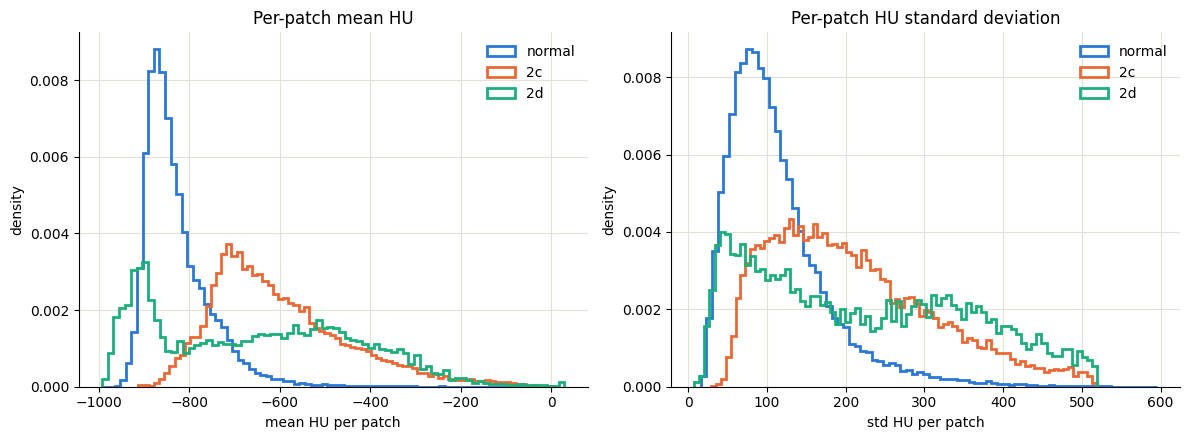

,class,n_patches,mean_of_patch_means,std_of_patch_means,mean_of_patch_stds,std_of_patch_stds
0,normal,53700,-827.419641,74.806886,113.091514,65.198133
1,2c,19217,-598.655456,152.518675,208.947491,103.309860
2,2d,10634,-649.619740,221.995850,220.321090,135.770970


In [50]:
import matplotlib.pyplot as plt
import numpy as np

HU_SCALE = 1000  # patches were divided by this at extraction time (see LOWER_HU/UPPER_HU)

patch_mean_hu = X_train.mean(axis=1) * HU_SCALE
patch_std_hu = X_train.std(axis=1) * HU_SCALE

# fixed categorical order/colors -- normal, 2c, 2d
CLASS_COLORS = {"normal": "#2a78d6", "2c": "#eb6834", "2d": "#1baf7a"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, cls in enumerate(CLASS_ORDER):
    mask = y_train == i
    axes[0].hist(
        patch_mean_hu[mask], bins=80, density=True, histtype="step",
        linewidth=2, color=CLASS_COLORS[cls], label=cls,
    )
    axes[1].hist(
        patch_std_hu[mask], bins=80, density=True, histtype="step",
        linewidth=2, color=CLASS_COLORS[cls], label=cls,
    )

for ax, title, xlabel in zip(
    axes,
    ["Per-patch mean HU", "Per-patch HU standard deviation"],
    ["mean HU per patch", "std HU per patch"],
):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

per_class_hu_stats = []
for i, cls in enumerate(CLASS_ORDER):
    mask = y_train == i
    per_class_hu_stats.append({
        "class": cls,
        "n_patches": int(mask.sum()),
        "mean_of_patch_means": patch_mean_hu[mask].mean(),
        "std_of_patch_means": patch_mean_hu[mask].std(),
        "mean_of_patch_stds": patch_std_hu[mask].mean(),
        "std_of_patch_stds": patch_std_hu[mask].std(),
    })
pd.DataFrame(per_class_hu_stats)


## EDA: per-patch HU table (every patch, one row each)

Same HU rescaling as above, but unbinned -- one row per training
patch instead of a class-level distribution.


In [68]:
# one row per patch: its own mean HU and std HU, not a binned summary
per_patch_hu = pd.DataFrame({
    "patch_idx": np.arange(len(X_train)),
    "scan_id": groups_train,
    "class": [CLASS_ORDER[i] for i in y_train],
    "mean_hu": patch_mean_hu,
    "std_hu": patch_std_hu,
})
print(f"{len(per_patch_hu)} patches, one row each")
per_patch_hu


83551 patches, one row each


,patch_idx,scan_id,class,mean_hu,std_hu
0,0,train_4451_a_1,normal,-781.230604,200.280064
1,1,train_122_b_1,2c,-375.946952,241.101824
2,2,train_2542_a_2,normal,-888.602314,125.354588
3,3,train_19567_a_2,normal,-797.967768,74.266686
4,4,train_2055_a_1,normal,-838.424705,117.474240
...,...,...,...,...,...
83546,83546,train_17169_a_2,normal,-857.937516,78.033301
83547,83547,train_19567_a_2,normal,-800.060042,74.186588
83548,83548,train_17169_a_2,normal,-871.945304,38.550825
83549,83549,train_10990_a_1,normal,-871.618376,74.704450


## Visualise: per-patch HU table (unbinned scatter)

Plots `per_patch_hu` directly, one point per patch, against its row
index in the table -- mean HU and std HU each as their own panel,
colored by class. Since the source file is pre-shuffled
(`unified_train_shuffled.npz`), `patch_idx` carries no ordering
information; this shows each individual patch's value rather than a
binned/aggregated distribution.


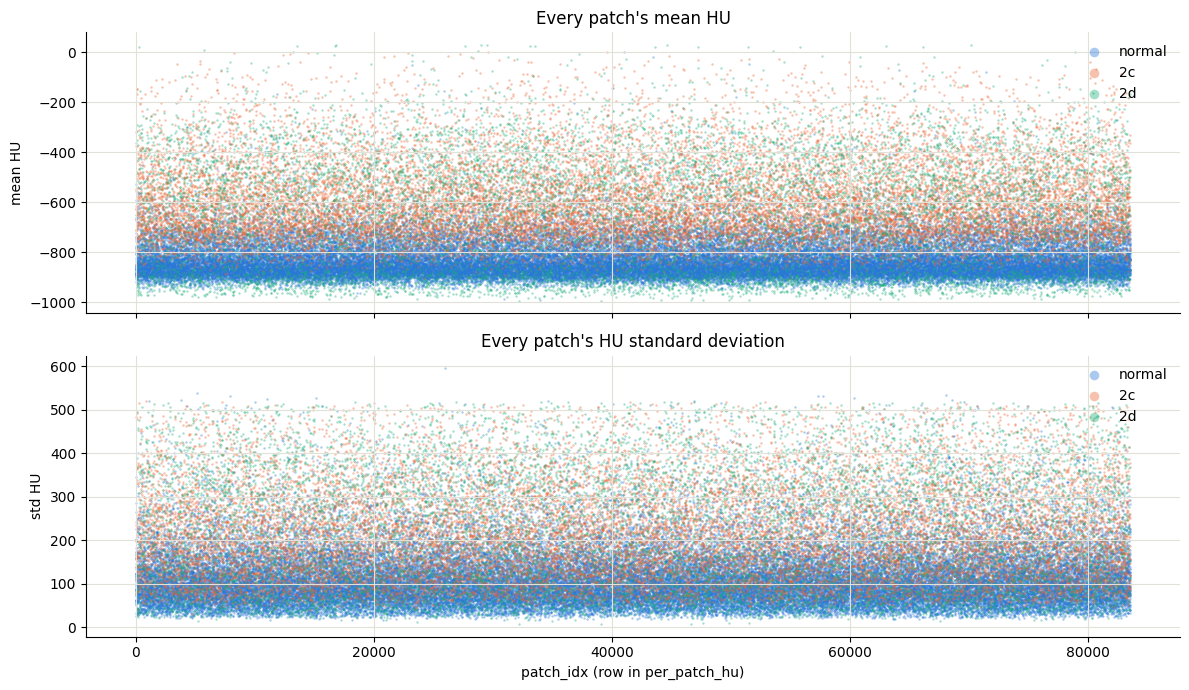

In [52]:
# visualise per_patch_hu itself: each patch plotted individually (by its
# position in the table), not binned into a histogram
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for cls in CLASS_ORDER:
    sub = per_patch_hu[per_patch_hu["class"] == cls]
    axes[0].scatter(
        sub["patch_idx"], sub["mean_hu"], s=3, alpha=0.4,
        color=CLASS_COLORS[cls], label=cls, linewidths=0,
    )
    axes[1].scatter(
        sub["patch_idx"], sub["std_hu"], s=3, alpha=0.4,
        color=CLASS_COLORS[cls], label=cls, linewidths=0,
    )

axes[0].set_title("Every patch's mean HU")
axes[0].set_ylabel("mean HU")
axes[1].set_title("Every patch's HU standard deviation")
axes[1].set_ylabel("std HU")
axes[1].set_xlabel("patch_idx (row in per_patch_hu)")

for ax in axes:
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, markerscale=4)

fig.tight_layout()
plt.show()


## Visualise: mean HU vs. std HU scatter (every patch) + export

Plots every training patch as a single point in (mean_hu, std_hu) space,
colored by class -- an unbinned view of the same two features
`hu_logreg_pipeline` trains on, showing how separable normal/2c/2d
actually are in that 2D space. Also exports the full `per_patch_hu` table
(83k+ rows) to `per_patch_hu_stats_train.csv` for inspection outside the
notebook.


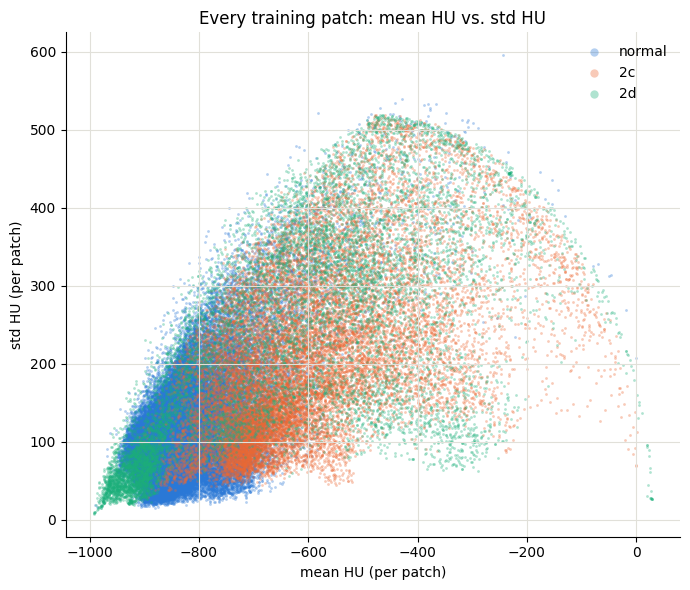

Saved -> outputs/per_patch_hu_stats_train.csv


In [67]:
fig, ax = plt.subplots(figsize=(7, 6))

for cls in CLASS_ORDER:
    sub = per_patch_hu[per_patch_hu["class"] == cls]
    ax.scatter(
        sub["mean_hu"], sub["std_hu"], s=4, alpha=0.35,
        color=CLASS_COLORS[cls], label=cls, linewidths=0,
    )

ax.set_title("Every training patch: mean HU vs. std HU")
ax.set_xlabel("mean HU (per patch)")
ax.set_ylabel("std HU (per patch)")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
leg = ax.legend(frameon=False, markerscale=3)
fig.tight_layout()
plt.show()

# full per-patch table, one row per patch -- export if you want to inspect all 83k rows outside the notebook
per_patch_hu.to_csv(MODELS_DIR.parent / "per_patch_hu_stats_train.csv", index=False)
print(f"Saved -> {MODELS_DIR.parent / 'per_patch_hu_stats_train.csv'}")


## Train: Logistic Regression on (mean_hu, std_hu) only

Instead of the full 1728-dim flattened patch, this reduces each patch to
just two summary statistics -- mean HU and std HU (computed earlier in
`per_patch_hu`) -- as the feature vector, with the patch's class as the
label. Prints every patch's input row before training so the raw
(mean_hu, std_hu, label) triples going into the model are visible one by
one, not just aggregated.


In [53]:
# input per patch: (mean_hu, std_hu) as features, class as the label
X_hu_features = per_patch_hu[["mean_hu", "std_hu"]].to_numpy()
y_hu_labels = per_patch_hu["class"].map({cls: i for i, cls in enumerate(CLASS_ORDER)}).to_numpy()

# print every patch's input row one by one before training
for i in range(len(per_patch_hu)):
    print(
        f"patch {i}: mean_hu={X_hu_features[i, 0]:.2f}, "
        f"std_hu={X_hu_features[i, 1]:.2f}, label={per_patch_hu['class'].iloc[i]}"
    )


patch 0: mean_hu=-781.23, std_hu=200.28, label=normal
patch 1: mean_hu=-375.95, std_hu=241.10, label=2c
patch 2: mean_hu=-888.60, std_hu=125.35, label=normal
patch 3: mean_hu=-797.97, std_hu=74.27, label=normal
patch 4: mean_hu=-838.42, std_hu=117.47, label=normal
patch 5: mean_hu=-808.30, std_hu=157.64, label=normal
patch 6: mean_hu=-881.10, std_hu=79.48, label=normal
patch 7: mean_hu=-710.47, std_hu=201.87, label=2c
patch 8: mean_hu=-797.30, std_hu=172.51, label=normal
patch 9: mean_hu=-889.51, std_hu=160.03, label=normal
patch 10: mean_hu=-868.55, std_hu=63.50, label=normal
patch 11: mean_hu=-823.95, std_hu=85.83, label=normal
patch 12: mean_hu=-737.23, std_hu=138.80, label=2c
patch 13: mean_hu=-870.59, std_hu=59.77, label=normal
patch 14: mean_hu=-736.69, std_hu=346.20, label=normal
patch 15: mean_hu=-867.52, std_hu=55.06, label=normal
patch 16: mean_hu=-787.56, std_hu=118.40, label=normal
patch 17: mean_hu=-554.88, std_hu=108.67, label=2c
patch 18: mean_hu=-887.73, std_hu=113.79, 

## Fit: Logistic Regression on (mean_hu, std_hu)

Scales the two features with `MaxAbsScaler` and fits a `class_weight="balanced"`
Logistic Regression directly on `(X_hu_features, y_hu_labels)` -- no CV/grid
search here, just a single fit on the full training set, to see how far two
summary statistics alone get a linear classifier. Prints the learned
coefficients and intercept for each class's decision boundary.


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline

hu_logreg_pipeline = Pipeline([
    ("scaler", MaxAbsScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced")),
])
hu_logreg_pipeline.fit(X_hu_features, y_hu_labels)

print("Trained LogisticRegression on (mean_hu, std_hu) features")
print("Coefficients:\n", hu_logreg_pipeline.named_steps["logreg"].coef_)
print("Intercept:\n", hu_logreg_pipeline.named_steps["logreg"].intercept_)


Trained LogisticRegression on (mean_hu, std_hu) features
Coefficients:
 [[-5.92723668 -0.98226147]
 [ 4.3734487  -0.53735389]
 [ 1.55378798  1.51961535]]
Intercept:
 [-4.19856739  3.35942136  0.83914604]


## Load test patches: (mean_hu, std_hu) table

Same HU rescaling and per-patch mean/std computation as `per_patch_hu`,
applied to the test split (`X_test`/`y_test`/`scan_ids_test`) instead of
train -- one row per test patch, ready to feed into `hu_logreg_pipeline`
for evaluation.


In [55]:
# build the same (mean_hu, std_hu) feature set for the test patches
HU_SCALE = 1000
test_mean_hu = X_test.mean(axis=1) * HU_SCALE
test_std_hu = X_test.std(axis=1) * HU_SCALE

per_patch_hu_test = pd.DataFrame({
    "patch_idx": np.arange(len(X_test)),
    "scan_id": scan_ids_test,
    "class": [CLASS_ORDER[i] for i in y_test],
    "mean_hu": test_mean_hu,
    "std_hu": test_std_hu,
})
print(f"{len(per_patch_hu_test)} test patches, one row each")
per_patch_hu_test


69571 test patches, one row each


,patch_idx,scan_id,class,mean_hu,std_hu
0,0,train_16110_a_1,normal,-911.312335,117.553530
1,1,train_16110_a_1,normal,-874.268654,127.122296
2,2,train_16110_a_1,normal,-931.211823,112.284255
3,3,train_16110_a_1,normal,-926.265973,93.420760
4,4,train_16110_a_1,normal,-863.709732,126.058057
...,...,...,...,...,...
69566,69566,valid_90_c_2,2d,-448.152396,491.606123
69567,69567,valid_90_c_2,2d,-504.204202,414.850486
69568,69568,valid_90_c_2,2d,-509.300147,418.567237
69569,69569,valid_90_c_2,2d,-543.969074,462.199941


## Evaluate: Logistic Regression on (mean_hu, std_hu)

Predicts on the test set's `(mean_hu, std_hu)` features with
`hu_logreg_pipeline`, prints the accuracy/classification report/confusion
matrix via `evaluate()`, and saves the results with
`save_classification_results()` under model name `hu_meanstd_logreg` --
matching the same save/evaluate pattern used for the full-patch models
above.


In [69]:
X_hu_features_test = per_patch_hu_test[["mean_hu", "std_hu"]].to_numpy()

y_pred_hu_logreg = hu_logreg_pipeline.predict(X_hu_features_test)
np.save(pred_path("hu_meanstd_logreg"), y_pred_hu_logreg)

print("=== (mean_hu, std_hu) LogisticRegression ===")
evaluate(y_pred_hu_logreg, y_test)

save_classification_results(
    predictions=y_pred_hu_logreg,
    labels=y_test,
    scan_ids=scan_ids_test,
    model_name="hu_meanstd_logreg",
    model_config={"logreg_params": hu_logreg_pipeline.named_steps["logreg"].get_params()},
    split="test",
)


INFO Saved classification results -> outputs/results/hu_meanstd_logreg_test_20260807_165400


=== (mean_hu, std_hu) LogisticRegression ===
Accuracy: 0.8084

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90     58764
           1       0.55      0.63      0.59      8019
           2       0.14      0.44      0.21      2788

    accuracy                           0.81     69571
   macro avg       0.55      0.64      0.57     69571
weighted avg       0.88      0.81      0.84     69571


Confusion Matrix:
[[49988  2684  6092]
 [ 1687  5034  1298]
 [  104  1466  1218]]


PosixPath('outputs/results/hu_meanstd_logreg_test_20260807_165400')